In [1]:
# Standard
import os, types
import math
import tempfile
import torch
import time

# Third Party
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK
import numpy as np
import pandas as pd
from botocore.client import Config
from tsfm_public.toolkit.lr_finder import optimal_lr_finder

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# tsfm library
from tsfm_public import (
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
    get_datasets
)
from tsfm_public.toolkit.visualization import plot_predictions
from tsfm_public.toolkit.get_model import get_model

In [3]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# TTM model branch
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

# Forecasting parameters
CONTEXT_LENGTH = 512

# Granite-TTM-R2 supports forecast length upto 720 and Granite-TTM-R1 supports forecast length upto 96
PREDICTION_LENGTH = 96

# Results dir
OUT_DIR = "/TTM/"

In [4]:
timestamp_column = "DATE"
id_columns = []
from pathlib import Path

dataset_name = "webbrowsing_train.csv"
data_file = Path.cwd().parents[1] / "data" / "filtered" / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"])
print("Loaded:", data_file)

Loaded: C:\Users\EJ17UF\OneDrive - Aalborg Universitet\Desktop\ms\data\filtered\webbrowsing_train.csv


In [5]:
target_columns = ["mac_dl_brate"]
control_columns = [col for col in df.columns if col not in target_columns]
id_columns = ["ue_ident"]

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": [],
    "target_columns": ["mac_dl_brate"],
    "control_columns": ["mac_dl_cqi","mac_dl_mcs","mac_dl_ok","mac_dl_nok"],
}

split_config =  {
    "train": 0.8,
    "test": 0.2,
}

In [6]:
def zeroshot_eval(dataset_name, batch_size, context_length=512, forecast_length=PREDICTION_LENGTH):
    # Get data

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="minmax",
    )

    # Load model
    zeroshot_model = get_model(
        TTM_MODEL_PATH,
        context_length=context_length,
        prediction_length=forecast_length,
        freq_prefix_tuning=False,
        freq='ms',
        prefer_l1_loss=False,
        prefer_longer_context=True,
    )

    param_size = sum(p.numel() * p.element_size() for p in zeroshot_model.parameters())
    print(f"TTM model parameters occupy ~{param_size/1024/1024:.2f} MB in memory")

    dset_train, dset_valid, dset_test = get_datasets(
        tsp, df, split_config, use_frequency_token=zeroshot_model.config.resolution_prefix_tuning
    )

    raw_timestamps = [item["timestamp"] for item in dset_test]
    test_timestamps = np.array(raw_timestamps)
    test_timestamps = pd.to_datetime(test_timestamps)

    cutoff = PREDICTION_LENGTH
    print('Cutoff value', cutoff)
    target_column_index = 0
    actuals = np.concatenate(
    [item["future_values"].numpy()[:, target_column_index:target_column_index+1] for item in dset_test],
    axis=0)

    actuals = actuals.reshape(-1, forecast_length)[:, :cutoff]
    print('Actuals Shape', actuals.shape)

    temp_dir = tempfile.mkdtemp()
    # zeroshot_trainer
    zeroshot_trainer = Trainer(
        model=zeroshot_model,
        args=TrainingArguments(
            output_dir=temp_dir,
            per_device_eval_batch_size=batch_size,
            seed=SEED,
            report_to="none",
        ),
    )
    # evaluate = zero-shot performance
    print("+" * 20, "Test MSE zero-shot", "+" * 20)
    zeroshot_output = zeroshot_trainer.evaluate(dset_test)
    print(zeroshot_output)

    # get predictions
    start_time = time.time()
    predictions_dict = zeroshot_trainer.predict(dset_test)
    end_time = time.time()

    inference_time = end_time - start_time
    num_samples = len(dset_test)
    inference_per_sample = inference_time / num_samples

    print(f"TTM Total Zero Shot inference time: {inference_time:.4f} seconds")
    print(f"TTM Zero Shot Inference time per sample: {inference_per_sample:.6f} seconds")

    predictions_np = predictions_dict.predictions[0]

    #print(predictions_np.shape)

    # get backbone embeddings (if needed for further analysis)

    backbone_embedding = predictions_dict.predictions[1]

    print(backbone_embedding.shape)

    predictions = predictions_dict.predictions
    #print(type(predictions))

    predictions = predictions[0]
    predictions = predictions_np[:, :, target_column_index]
    predictions = predictions.reshape(-1, forecast_length)[:, :cutoff]
    print('Predictions Shape', predictions.shape)


    predictions_avg = np.mean(predictions, axis=1)
    actuals_avg = np.mean(actuals, axis=1)


    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)

    return rmse, mae, predictions_avg, actuals_avg, test_timestamps

In [7]:
rmse_zs, mae_zs, predictions_zs, actuals_zs, test_timestamps = zeroshot_eval(
    dataset_name=df, context_length=CONTEXT_LENGTH, forecast_length=PREDICTION_LENGTH, batch_size=128
)

INFO:p-6728:t-2536:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2


INFO:p-6728:t-2536:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.


INFO:p-6728:t-2536:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


TTM model parameters occupy ~3.07 MB in memory


Cutoff value 96


Actuals Shape (3478, 96)
++++++++++++++++++++ Test MSE zero-shot ++++++++++++++++++++


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.013888736255466938, 'eval_model_preparation_time': 0.003, 'eval_runtime': 5.6609, 'eval_samples_per_second': 614.394, 'eval_steps_per_second': 4.946}


TTM Total Zero Shot inference time: 6.1290 seconds
TTM Zero Shot Inference time per sample: 0.001762 seconds
(3478, 5, 8, 192)
Predictions Shape (3478, 96)


In [8]:
print(rmse_zs)
print(mae_zs)

0.0717761727321884
0.04600432515144348


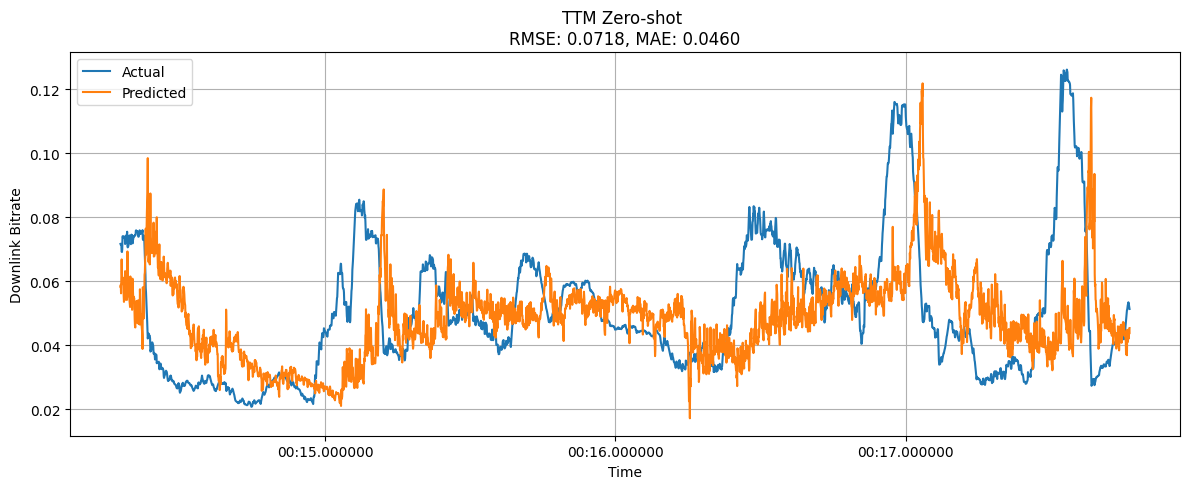

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(test_timestamps, actuals_zs, label='Actual')
plt.plot(test_timestamps, predictions_zs, label='Predicted')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Downlink Bitrate')
plt.title(f'TTM Zero-shot \nRMSE: {rmse_zs:.4f}, MAE: {mae_zs:.4f}')
plt.grid(True)
plt.tight_layout()
plt.show()

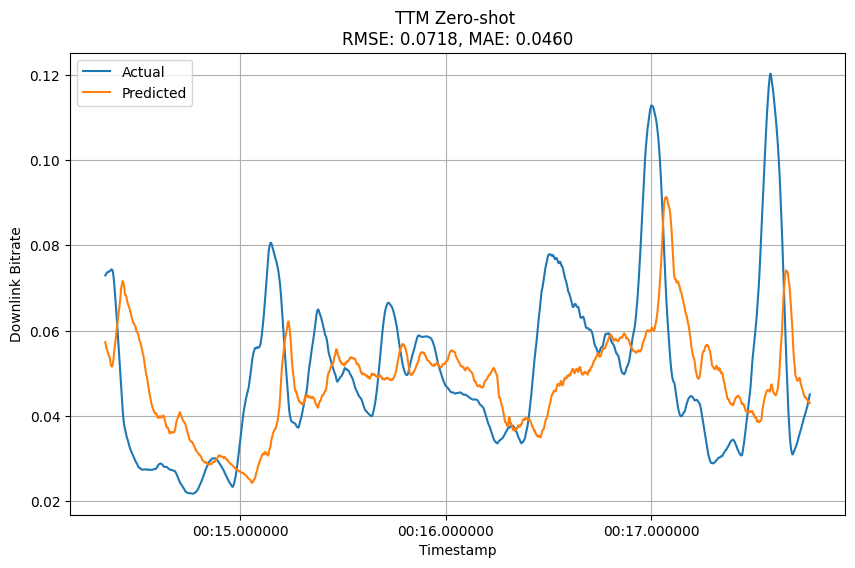

In [10]:
test_smooth = pd.Series(actuals_zs.ravel()).rolling(window=50).mean()
pred_smooth = pd.Series(predictions_zs.ravel()).rolling(window=50).mean()

plt.figure(figsize=(10, 6))
plt.plot(test_timestamps, test_smooth, label='Actual')
plt.plot(test_timestamps, pred_smooth, label='Predicted')
plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Downlink Bitrate')
plt.title(f'TTM Zero-shot \nRMSE: {rmse_zs:.4f}, MAE: {mae_zs:.4f}')
plt.grid(True)
plt.show()

In [11]:
def fewshot_finetune_eval(
    dataset_name,
    batch_size,
    learning_rate=None,
    context_length=512,
    forecast_length=PREDICTION_LENGTH,
    fewshot_percent=0.1,
    freeze_backbone=True,
    num_epochs=30,
    save_dir=OUT_DIR,
    loss="mse",
    quantile=0.5,
):
    #out_dir = os.path.join(save_dir, dataset_name)

    print("-" * 20, f"Running few-shot {fewshot_percent}%", "-" * 20)

    # Data prep: Get dataset

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="minmax",
    )

    # change head dropout to 0.7 for ett datasets
    if "ett" in dataset_name:
        finetune_forecast_model = get_model(
            TTM_MODEL_PATH,
            context_length=context_length,
            prediction_length=forecast_length,
            freq_prefix_tuning=False,
            freq=None,
            prefer_l1_loss=False,
            prefer_longer_context=True,
            # Can also provide TTM Config args
            head_dropout=0.7,
            loss=loss,
            quantile=quantile,
        )
    else:
        finetune_forecast_model = get_model(
            TTM_MODEL_PATH,
            context_length=context_length,
            prediction_length=forecast_length,
            freq_prefix_tuning=False,
            freq=None,
            prefer_l1_loss=False,
            prefer_longer_context=True,
            # Can also provide TTM Config args
            loss=loss,
            quantile=quantile,
        )

    dset_train, dset_val, dset_test = get_datasets(
        tsp,
        df,
        split_config,
        fewshot_fraction=fewshot_percent / 100,
        fewshot_location="first",
        use_frequency_token=finetune_forecast_model.config.resolution_prefix_tuning,
    )

    if freeze_backbone:
        print(
            "Number of params before freezing backbone",
            count_parameters(finetune_forecast_model),
        )

        # Freeze the backbone of the model
        for param in finetune_forecast_model.backbone.parameters():
            param.requires_grad = False

        # Count params
        print(
            "Number of params after freezing the backbone",
            count_parameters(finetune_forecast_model),
        )

    
    # Find optimal learning rate
    # Use with caution: Set it manually if the suggested learning rate is not suitable
    if learning_rate is None:
        learning_rate, finetune_forecast_model = optimal_lr_finder(
            finetune_forecast_model,
            dset_train,
            batch_size=batch_size,
        )
        print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

    print(f"Using learning rate = {learning_rate}")
    finetune_forecast_args = TrainingArguments(
        output_dir=os.path.join(OUT_DIR, "finetune_output"),
        overwrite_output_dir=True,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        do_eval=True,
        eval_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=8,
        report_to="none",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        logging_dir=os.path.join(OUT_DIR, "finetune_logs"),  # Make sure to specify a logging directory
        load_best_model_at_end=True,  # Load the best model when training ends
        metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
        greater_is_better=False,  # For loss
        seed=SEED,
    )

    # Create the early stopping callback
    early_stopping_callback = EarlyStoppingCallback(
        early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
        early_stopping_threshold=1e-5,  # Minimum improvement required to consider as improvement
    )
    tracking_callback = TrackingCallback()

    # Optimizer and scheduler
    optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
    scheduler = OneCycleLR(
        optimizer,
        learning_rate,
        epochs=num_epochs,
        steps_per_epoch=math.ceil(len(dset_train) / (batch_size)),
    )

    finetune_forecast_trainer = Trainer(
        model=finetune_forecast_model,
        args=finetune_forecast_args,
        train_dataset=dset_train,
        eval_dataset=dset_val,
        callbacks=[early_stopping_callback, tracking_callback],
        optimizers=(optimizer, scheduler),
    )
    finetune_forecast_trainer.remove_callback(INTEGRATION_TO_CALLBACK["codecarbon"])

    # Fine tune
    finetune_forecast_trainer.train()

    # Evaluation
    print("+" * 20, f"Test MSE after few-shot {fewshot_percent}% fine-tuning", "+" * 20)

    finetune_forecast_trainer.model.loss = "mse"  # fixing metric to mse for evaluation

    fewshot_output = finetune_forecast_trainer.evaluate(dset_test)
    print(fewshot_output)
    print("+" * 60)

    raw_timestamps = [item["timestamp"] for item in dset_test]
    test_timestamps = np.array(raw_timestamps)
    test_timestamps = pd.to_datetime(test_timestamps)

    #print(dset_test[0].keys())

    cutoff = PREDICTION_LENGTH
    print('Cutoff length', cutoff)

    target_column_index = 0
    actuals = np.concatenate(
    [item["future_values"].numpy()[:, target_column_index:target_column_index+1] for item in dset_test],
    axis=0)

    actuals = actuals.reshape(-1, forecast_length)[:, :cutoff]
    print('Actuals Shape', actuals.shape)


    # get predictions
    start_time = time.time()
    predictions_dict = finetune_forecast_trainer.predict(dset_test)
    end_time = time.time()

    inference_time = end_time - start_time
    num_samples = len(dset_test)
    inference_per_sample = inference_time / num_samples

    print(f"TTM Total fientune inference time: {inference_time:.4f} seconds")
    print(f"TTM finetune Inference time per sample: {inference_per_sample:.6f} seconds")

    predictions_np = predictions_dict.predictions[0]

    print(predictions_np.shape)

    # get backbone embeddings (if needed for further analysis)

    backbone_embedding = predictions_dict.predictions[1]

    print(backbone_embedding.shape)

 
    predictions = predictions_dict.predictions
    #print(type(predictions))

    predictions = predictions[0]
    predictions = predictions_np[:, :, target_column_index]
    predictions = predictions.reshape(-1, forecast_length)[:, :cutoff]
    print('Predictions Shape', predictions.shape)


    predictions_avg = np.mean(predictions, axis=1)
    actuals_avg = np.mean(actuals, axis=1)


    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)

    return rmse, mae, predictions_avg, actuals_avg, test_timestamps

In [12]:
rmse, mae, predictions, actuals, timestamps = fewshot_finetune_eval(
    dataset_name=df,
    context_length=CONTEXT_LENGTH,
    forecast_length=PREDICTION_LENGTH,
    batch_size=128,
    fewshot_percent=10,
    learning_rate=None,
)

INFO:p-6728:t-2536:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2


-------------------- Running few-shot 10% --------------------


INFO:p-6728:t-2536:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.


INFO:p-6728:t-2536:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


INFO:p-6728:t-2536:lr_finder.py:optimal_lr_finder:LR Finder: Running learning rate (LR) finder algorithm. If the suggested LR is very low, we suggest setting the LR manually.


...

{'eval_loss': 0.0144650274887681, 'eval_runtime': 167.3266, 'eval_samples_per_second': 20.786, 'eval_steps_per_second': 0.167, 'epoch': 14.0}
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


Cutoff length 96


Actuals Shape (3478, 96)


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TTM Total fientune inference time: 179.3612 seconds
TTM finetune Inference time per sample: 0.051570 seconds
(3478, 96, 5)
(3478, 5, 8, 192)
Predictions Shape (3478, 96)


In [13]:
print(rmse)
print(mae)

0.07202573860664302
0.04883521795272827


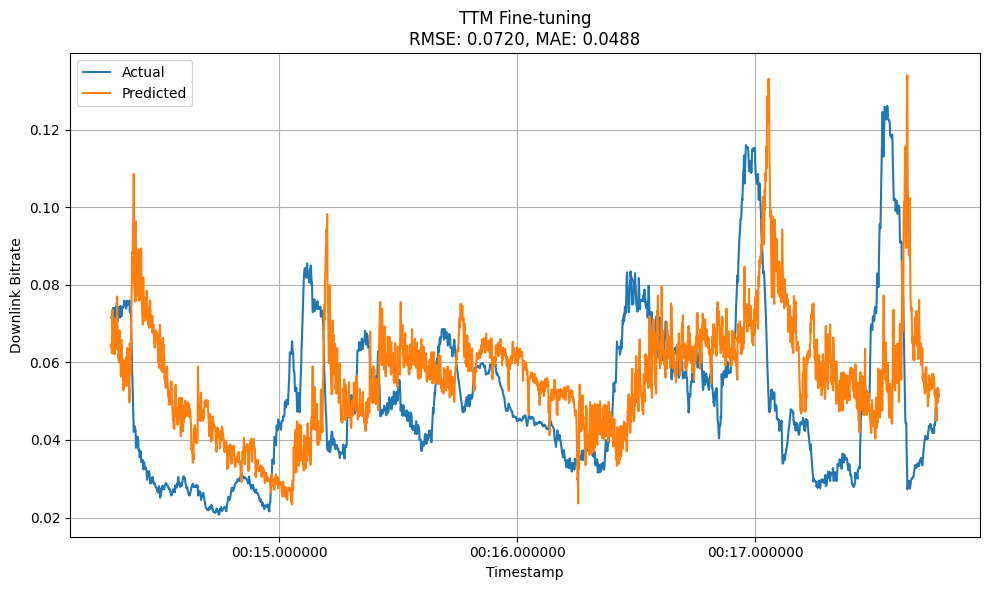

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(timestamps, actuals, label='Actual')
plt.plot(timestamps, predictions, label='Predicted')
plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Downlink Bitrate')
plt.title(f'TTM Fine-tuning\nRMSE: {rmse:.4f}, MAE: {mae:.4f}')
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
ft_pred_smooth = pd.Series(predictions.ravel()).rolling(window=50).mean()

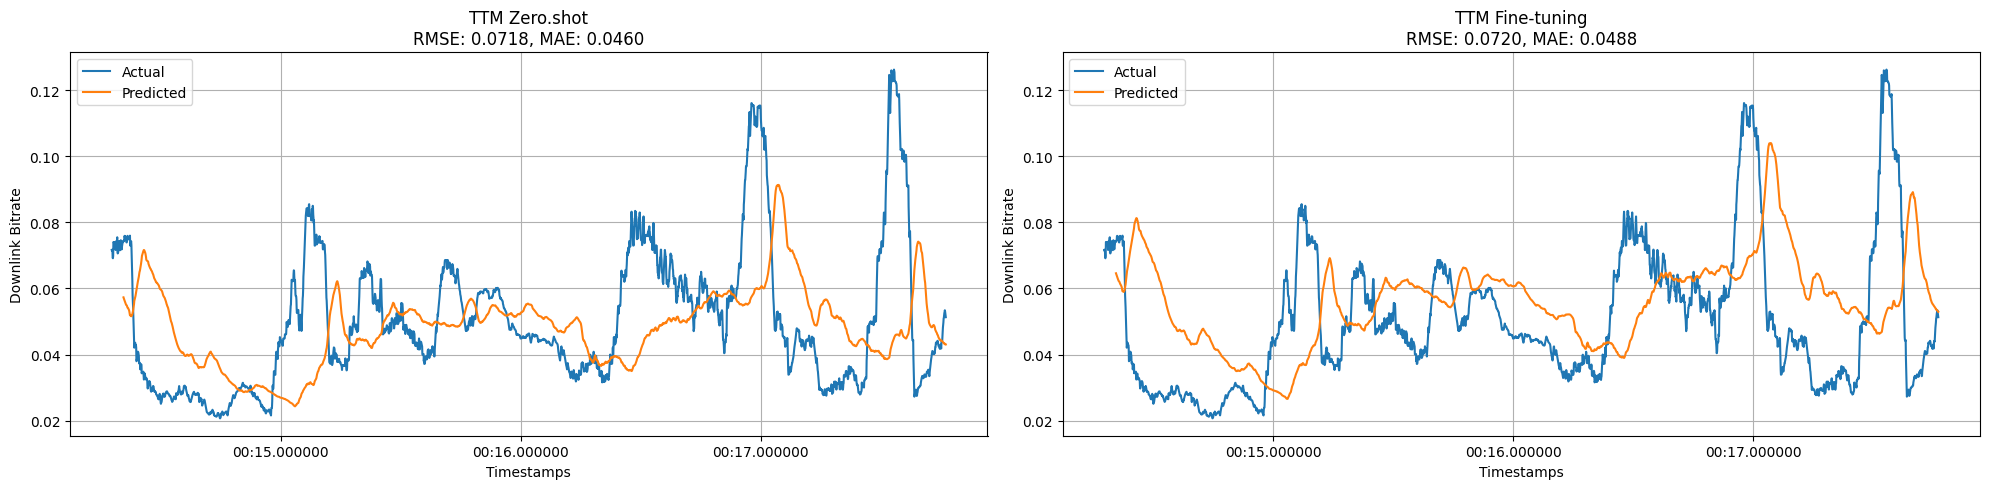

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].plot(test_timestamps, actuals_zs, label='Actual')
axs[0].plot(test_timestamps, pred_smooth, label='Predicted')
axs[0].set_title(f'TTM Zero.shot\nRMSE: {rmse_zs:.4f}, MAE: {mae_zs:.4f}')
axs[0].set_xlabel('Timestamps')
axs[0].set_ylabel('Downlink Bitrate')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(timestamps, actuals, label='Actual')
axs[1].plot(timestamps, ft_pred_smooth, label='Predicted')
axs[1].set_title(f'TTM Fine-tuning\nRMSE: {rmse:.4f}, MAE: {mae:.4f}')
axs[1].set_xlabel('Timestamps')
axs[1].set_ylabel('Downlink Bitrate')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
results_dir = Path("../results/metrics/web_browsing")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([
    {
        "model": "TTM",
        "variant": "zero_shot",
        "setting": "multivariate",
        "dataset": "web_browsing",
        "rmse": rmse_zs,
        "mae": mae_zs,
    },
    {
        "model": "TTM",
        "variant": "fine_tuning",
        "setting": "multivariate",
        "dataset": "web_browsing",
        "rmse": rmse,
        "mae": mae,
    }
])

metrics_file = results_dir / "ttm_multivariate_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)
print(metrics_df)

Saved metrics to: ..\results\metrics\web_browsing\ttm_multivariate_metrics.csv
  model      variant       setting       dataset      rmse       mae
0   TTM    zero_shot  multivariate  web_browsing  0.071776  0.046004
1   TTM  fine_tuning  multivariate  web_browsing  0.072026  0.048835
